In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [ ]:
sign_language_data=pd.read_csv("/content/sign_language_data.csv")
print(sign_language_data.head())
print(sign_language_data.shape)

  letter        x0        y0            z0        x1        y1        z1  \
0    Ain  0.281848  0.770933  2.127359e-06  0.299459  0.581939  0.003215   
1    Ain  0.153687  0.627563  2.449348e-06  0.212909  0.540727 -0.023421   
2    Ain  0.025697  0.571254  2.139683e-06  0.117762  0.439931  0.017492   
3    Ain  0.114419  0.846487  7.563933e-07  0.133112  0.608031  0.041805   
4    Ain  0.297838  0.834262  9.990022e-07  0.329022  0.666287 -0.002941   

         x2        y2        z2  ...       z17       x18       y18       z18  \
0  0.407830  0.460463 -0.044538  ... -0.232573  0.612845  0.683520 -0.210898   
1  0.318150  0.499655 -0.086765  ... -0.259077  0.424218  0.697448 -0.285401   
2  0.267403  0.373269 -0.000136  ... -0.118686  0.410647  0.623118 -0.082564   
3  0.228139  0.528467  0.111665  ...  0.169150  0.365031  0.768893  0.237965   
4  0.363154  0.540206 -0.032642  ... -0.141643  0.415088  0.705962 -0.169957   

        x19       y19       z19       x20       y20       z20 

In [ ]:
encoder = LabelEncoder()
sign_language_data["letter"] = encoder.fit_transform(sign_language_data['letter'])
print(sign_language_data.head())

   letter        x0        y0            z0        x1        y1        z1  \
0       0  0.281848  0.770933  2.127359e-06  0.299459  0.581939  0.003215   
1       0  0.153687  0.627563  2.449348e-06  0.212909  0.540727 -0.023421   
2       0  0.025697  0.571254  2.139683e-06  0.117762  0.439931  0.017492   
3       0  0.114419  0.846487  7.563933e-07  0.133112  0.608031  0.041805   
4       0  0.297838  0.834262  9.990022e-07  0.329022  0.666287 -0.002941   

         x2        y2        z2  ...       z17       x18       y18       z18  \
0  0.407830  0.460463 -0.044538  ... -0.232573  0.612845  0.683520 -0.210898   
1  0.318150  0.499655 -0.086765  ... -0.259077  0.424218  0.697448 -0.285401   
2  0.267403  0.373269 -0.000136  ... -0.118686  0.410647  0.623118 -0.082564   
3  0.228139  0.528467  0.111665  ...  0.169150  0.365031  0.768893  0.237965   
4  0.363154  0.540206 -0.032642  ... -0.141643  0.415088  0.705962 -0.169957   

        x19       y19       z19       x20       y20     

In [ ]:



X = sign_language_data.iloc[:, 1:].values
y = sign_language_data.iloc[:, 0].values


y_categorical = to_categorical(y)


X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


print(f"عدد العينات: {sign_language_data.shape[0]}")
print(f"عدد الفئات: {len(encoder.classes_)}")


عدد العينات: 7137
عدد الفئات: 31


In [ ]:

model = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(len(encoder.classes_), activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))





Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0697 - loss: 3.3451 - val_accuracy: 0.2668 - val_loss: 2.3074
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3061 - loss: 2.1383 - val_accuracy: 0.5357 - val_loss: 1.4516
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4778 - loss: 1.4662 - val_accuracy: 0.6779 - val_loss: 1.0118
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5910 - loss: 1.1396 - val_accuracy: 0.7423 - val_loss: 0.7912
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6729 - loss: 0.9354 - val_accuracy: 0.8109 - val_loss: 0.6577
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7070 - loss: 0.8115 - val_accuracy: 0.8263 - val_loss: 0.5583
Epoch 7/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7474 - loss: 0.7066 - val_accuracy: 0.8789 - val_loss: 0.4671
Epoch 8/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7738 - loss: 0.6559 - val_accuracy: 0.881

In [ ]:

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.1525
Test Accuracy: 96.71%


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


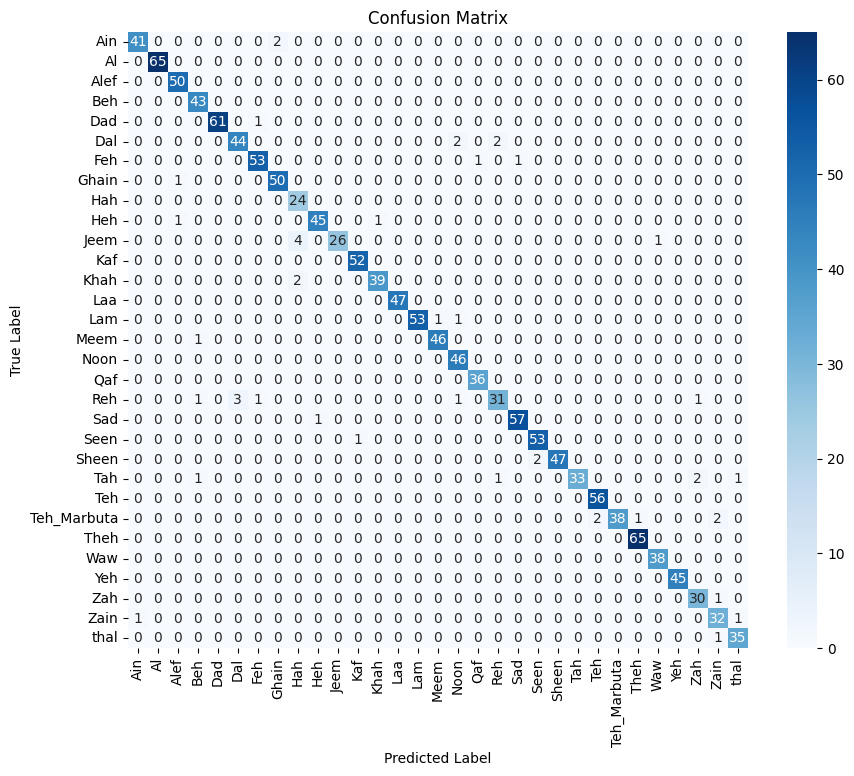

In [ ]:

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:

print(classification_report(y_true, y_pred_classes, target_names=encoder.classes_))


              precision    recall  f1-score   support

         Ain       0.98      0.95      0.96        43
          Al       1.00      1.00      1.00        65
        Alef       0.96      1.00      0.98        50
         Beh       0.93      1.00      0.97        43
         Dad       1.00      0.98      0.99        62
         Dal       0.94      0.92      0.93        48
         Feh       0.96      0.96      0.96        55
       Ghain       0.96      0.98      0.97        51
         Hah       0.80      1.00      0.89        24
         Heh       0.98      0.96      0.97        47
        Jeem       1.00      0.84      0.91        31
         Kaf       0.98      1.00      0.99        52
        Khah       0.97      0.95      0.96        41
         Laa       1.00      1.00      1.00        47
         Lam       1.00      0.96      0.98        55
        Meem       0.98      0.98      0.98        47
        Noon       0.92      1.00      0.96        46
         Qaf       0.97    